<a href="https://colab.research.google.com/github/WellsAr/Mortality-Modelling---Randomised-CUSUM-Lee-Ccarter/blob/main/Rand_CUSUM_LC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA


In [2]:
# helper functions

def retrieve_data(file_name):

    with open(file_name) as f:
        g = f.readlines()

    data = []

    for item in g:
        l = item.strip().split(' ')
        d = []
        for e in l:
            e = e.strip('+')
            if len(e) >= 1:
                if e == '.':
                    d.append(0)
                else:
                    d.append(e)

        data.append(d)

    year = []
    age = []
    female = []
    male = []
    total = []

    for el in data[3:]:
        year.append(int(el[0]))
        age.append(int(el[1]))
        female.append(float(el[2]))
        male.append(float(el[3]))
        total.append(float(el[4]))

    dd = {}
    dd['Year'] = year
    dd['Age'] = age
    dd['Female'] = female
    dd['Male'] = male
    dd['Total'] = total

    return pd.DataFrame(dd)


def find_globally_valid_start_year(df, min_age, max_age):

    years = np.sort(df['Year'].unique())

    # Precompute validity of each year
    year_valid = {}

    for y in years:
        sub = df[
            (df['Year'] == y) &
            (df['Age'] >= min_age) &
            (df['Age'] <= max_age)
        ]

        # Full age coverage
        if sub['Age'].nunique() != (max_age - min_age + 1):
            year_valid[y] = False
            continue

        mx = sub['mx'].values
        year_valid[y] = np.all(np.isfinite(mx)) and np.all(mx > 0)

    # Find earliest year such that ALL later years are valid
    for i, y in enumerate(years):
        if all(year_valid[yy] for yy in years[i:]):
            return y

    raise ValueError(
        "No contiguous block of years with complete mx data for the chosen age range."
    )


def prepare_mortality_df(df, config):

    df = df.rename(columns={'Total': 'mx'})
    df = df.drop(columns=['Female', 'Male'], errors='ignore')

    # find first year with valid mx
    min_year = find_globally_valid_start_year(
        df,
        config["min_age"],
        config["max_age"]
    )

    # drop everything before (and including invalid years)
    df = df[df['Year'] >= min_year].copy()

    max_year = df['Year'].max()

    df = df[
        (df['Age'] >= config["min_age"]) &
        (df['Age'] <= config["max_age"])
    ].reset_index(drop=True)

    # build age x year matrix
    mort_list = []
    for age in range(config["min_age"], config["max_age"] + 1):
        mort_list.append(df[df['Age'] == age]['mx'].values)

    mort_df = pd.DataFrame(
        np.array(mort_list),
        index=range(config["min_age"], config["max_age"] + 1),
        columns=range(min_year, max_year + 1)
    )

    return mort_df



def train_test_split_lc(mort_df, train_ratio):

    mort_df_t = mort_df.T
    n_total = len(mort_df_t)

    split_idx = int(np.round(n_total * train_ratio))

    train_df = mort_df_t.iloc[:split_idx]
    test_df = mort_df_t.iloc[split_idx:]

    # infer years
    train_years = train_df.index
    test_years = test_df.index

    forecast_horizon = len(test_years)

    return train_df, test_df, forecast_horizon


def estimate_lee_carter(train_df):

    log_mort_df = np.log(train_df)

    ## average log mortality rates
    ax = log_mort_df.mean()

    ## centering log mortality rates
    centered_log_mort_rates = log_mort_df - ax
    centered_log_mort_rates = centered_log_mort_rates.transpose()

    # Singular Value Decomposition (SVD)

    U, s, Vt = np.linalg.svd(centered_log_mort_rates, full_matrices=False)

    ## bx
    bx = U[:, 0]

    ## normalize bx
    bx_sum = np.sum(bx)
    bx = bx/bx_sum

    ## extract and normalize kt
    kt = s[0] * Vt[0] * bx_sum

    return ax, bx, kt


def forecast_rw_with_drift(kt_segment, horizon):

    drift = np.mean(np.diff(kt_segment))
    forecast = [kt_segment[-1]]

    for _ in range(horizon):
        forecast.append(forecast[-1] + drift)

    return np.array(forecast[1:])


def cusum_weighted_breaks(kt, v_values):

    dkt = np.diff(kt)
    n = len(dkt)

    sigma = dkt.std(ddof=1)
    total = dkt.sum()

    rows = []
    for v in v_values:
        for k in range(1, n):
            adj = dkt[:k].sum() - (k / n) * total
            cusum = abs(adj) / (sigma * np.sqrt(n))
            weight = ((n**2) / (k * (n - k)))**v
            rows.append({"v": v, "k": k, "CUSUM": cusum * weight})

    df = pd.DataFrame(rows)

    return df.loc[df.groupby("v")["CUSUM"].idxmax()], df


def forecast_all_scenarios(ax, bx, kt, breaks, break_y, horizon):

    forecasts = {}

    # Base LC
    kt_fc = forecast_rw_with_drift(kt, horizon)
    forecasts["Base LC"] = lee_carter_model(ax, bx, kt_fc)

    # Break-based forecasts
    for k, by in zip(breaks, break_y):
        kt_seg = kt[k:]

        kt_fc = forecast_rw_with_drift(kt_seg, horizon)
        forecasts[f"Break@year={by}"] = lee_carter_model(ax, bx, kt_fc)

    return forecasts


def lee_carter_model(ax, bx, kt):

    ax = np.asarray(ax)
    bx = np.asarray(bx)
    kt = np.asarray(kt)

    # ax + bx * kt
    log_mx = ax[:, None] + np.outer(bx, kt)

    mx = np.exp(log_mx)
    return mx


def lc_error_metrics(y_true, y_pred, eps=1e-8):

    y_true = np.asarray(y_true).astype(float).ravel()
    y_pred = np.asarray(y_pred).astype(float).ravel()

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))
    ) * 100

    return {
        "MSE": f"{mse:.6e}",
        "RMSE": f"{rmse:.6e}",
        "MAE": f"{mae:.6e}",
        "MAPE (%)": f"{mape:.6e}"
    }



def build_metric_table(actual_df, pred_df):

    metrics = {}

    # Flatten for metrics calculation
    y_true = actual_df.values
    y_pred = pred_df.values

    metrics["Lee-Carter"] = lc_error_metrics(y_true, y_pred)

    metric_df = pd.DataFrame(metrics)
    return metric_df



def wrap_forecasts_as_df(forecasts, test_years, ages):

    wrapped = {}
    for label, mx in forecasts.items():
        wrapped[label] = pd.DataFrame(
            mx,
            index=ages,
            columns=test_years
        )

    return wrapped


def prep_data_gh(file):

    data = pd.read_csv(file)

    data = data.dropna()

    mort_rates = []
    for year in range(2010, 2021):
        mort_rates.append(data[f'{year}']/data[f'{year}.1'])

    mort_rates = np.array(mort_rates)
    mort_df = pd.DataFrame(mort_rates)
    mort_df.columns = list(range(40, 84))
    mort_df.index = list(range(2010, 2021))

    return mort_df.T


def compute_summary_stats(mort_df):
    raw_vals = mort_df.values
    log_vals = np.log(raw_vals)

    raw_stats = {
        "Mean": raw_vals.mean(),
        "Std. Dev.": raw_vals.std(),
        "Min": raw_vals.min(),
        "Max": raw_vals.max()
    }

    log_stats = {
        "Mean": log_vals.mean(),
        "Std. Dev.": log_vals.std(),
        "Min": log_vals.min(),
        "Max": log_vals.max()
    }

    return raw_stats, log_stats



def plot_last_year_actual_vs_pred(country, actual_df, pred_df):

    last_year = actual_df.columns[-1]  # Last year in training

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        actual_df.index,
        actual_df[last_year],
        linestyle="--",
        marker="o",
        label=f"Actual {last_year}"
    )

    ax.plot(
        pred_df.index,
        pred_df[last_year],
        linestyle="-",
        marker="x",
        label=f"Predicted {last_year}"
    )

    ax.set_title(f"Actual vs Predicted Mortality – {country} ({last_year})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Mortality rate")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()




def plot_last_two_years_grid(country, actual_df, pred_df):

    last_years = actual_df.columns[-2:]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for i, yr in enumerate(last_years):
        ax = axes[i]
        ax.plot(
            actual_df.index,
            actual_df[yr],
            linestyle="-",
            marker="o",
            label=f"Actual {yr}"
        )
        ax.plot(
            pred_df.index,
            pred_df[yr],
            linestyle="--",
            marker="x",
            label=f"Predicted {yr}"
        )
        ax.set_title(f"{country} - {yr}")
        ax.set_xlabel("Age")
        if i == 0:
            ax.set_ylabel("Mortality Rate")
        ax.legend()
        ax.grid(True)

    plt.suptitle(f"{country}: Actual vs Predicted Mortality (Last 2 Years)")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()




def plot_base_vs_break_all_countries(all_country_forecasts, save_path=None, download=False):

    n_countries = len(all_country_forecasts)

    fig, axes = plt.subplots(
        n_countries, 2,
        figsize=(12, 2 * n_countries),
        sharex=False,
        sharey=False
    )

    if n_countries == 1:
        axes = axes.reshape(1, 2)

    for i, (country, data) in enumerate(all_country_forecasts.items()):

        actual_df = data["actual"]
        forecast_dict = data["forecasts"]

        last_year = actual_df.columns[-1]
        ages = actual_df.index

        # ---------- Base LC ----------
        base_pred = forecast_dict["Base LC"]

        axes[i, 0].plot(
            ages,
            actual_df[last_year],
            label="Actual",
            linewidth=2
        )
        axes[i, 0].plot(
            ages,
            base_pred[last_year],
            label="Base LC"
        )

        axes[i, 0].set_title(
            f"{country} – {last_year} (Base LC)",
            fontsize=11
        )
        axes[i, 0].set_xlabel("Age")
        axes[i, 0].set_ylabel("Mortality rate")
        axes[i, 0].grid(alpha=0.3)
        axes[i, 0].legend()

        # ---------- Break LC ----------
        break_models = [k for k in forecast_dict.keys() if k != "Base LC"]

        if break_models:
            break_name = break_models[0]
            break_pred = forecast_dict[break_name]

            axes[i, 1].plot(
                ages,
                actual_df[last_year],
                label="Actual",
                linewidth=2
            )
            axes[i, 1].plot(
                ages,
                break_pred[last_year],
                label=break_name
            )

        axes[i, 1].set_title(
            f"{country} – {last_year} (Break LC)",
            fontsize=11
        )
        axes[i, 1].set_xlabel("Age")
        axes[i, 1].grid(alpha=0.3)
        axes[i, 1].legend()

    fig.suptitle(
        "Out of Sample Actual vs Forecasted Mortality Rates",
        fontsize=15
    )

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # ---------- Save ----------
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    if download == True:
      files.download(save_path)


def build_country_forecast_metrics(actual_df, forecast_dfs):

    metrics = {}

    # Align shapes defensively
    y_true = actual_df.values

    for label, pred_df in forecast_dfs.items():
        y_pred = pred_df.values

        metrics[label] = lc_error_metrics(y_true, y_pred)

    return pd.DataFrame(metrics)



In [3]:
CONFIG = {
    "min_age": 0,
    "max_age": 100,

    "train_ratio": 0.7,

    "cusum_v_values": np.linspace(0, 0.5, 5),
}

CONFIG_hnk = {
    "min_age": 12,
    "max_age": 100,

    "train_ratio": 0.7,

    "cusum_v_values": np.linspace(0, 0.5, 5),
}


**Exploratory Data Analysis**

In [4]:
from google.colab import files

# Open a file upload dialog
uploaded = files.upload()


Saving Deaths_Belgium_1x1.txt to Deaths_Belgium_1x1.txt
Saving Deaths_HongKong_1x1.txt to Deaths_HongKong_1x1.txt
Saving Deaths_USA_1x1.txt to Deaths_USA_1x1.txt
Saving DeathsGH.csv to DeathsGH.csv
Saving Exposures_Belgium_1x1.txt to Exposures_Belgium_1x1.txt
Saving Exposures_HongKong_1x1.txt to Exposures_HongKong_1x1.txt
Saving Exposures_USA_1x1.txt to Exposures_USA_1x1.txt
Saving Mx_Belgium_1x1.txt to Mx_Belgium_1x1.txt
Saving Mx_HongKong_1x1.txt to Mx_HongKong_1x1.txt
Saving Mx_USA_1x1.txt to Mx_USA_1x1.txt


In [5]:
tx_usa = 'Mx_USA_1x1.txt'
df_usa = retrieve_data(tx_usa)

tx_hnk = 'Mx_HongKong_1x1.txt'
df_hnk = retrieve_data(tx_hnk)

tx_bel = 'Mx_Belgium_1x1.txt'
df_bel = retrieve_data(tx_bel)

mort_usa_df = prepare_mortality_df(df_usa, CONFIG)
mort_hnk_df = prepare_mortality_df(df_hnk, CONFIG_hnk)
mort_bel_df = prepare_mortality_df(df_bel, CONFIG)
mort_gh_df = prep_data_gh('DeathsGH.csv')


In [6]:
mortality_dict = {
    "Ghana":  mort_gh_df,
    "USA": mort_usa_df,
    "Hong Kong": mort_hnk_df,
    "Belgium": mort_bel_df
}

raw_summary = {}

for country, mort_df in mortality_dict.items():
    raw_stats, _ = compute_summary_stats(mort_df)
    raw_summary[country] = raw_stats

raw_summary_df = pd.DataFrame(raw_summary)

log_summary = {}

for country, mort_df in mortality_dict.items():
    _, log_stats = compute_summary_stats(mort_df)
    log_summary[country] = log_stats

log_summary_df = pd.DataFrame(log_summary)

log_summary_df, raw_summary_df

(              Ghana       USA  Hong Kong    Belgium
 Mean      -4.511521 -4.798944  -5.261652  -4.734742
 Std. Dev.  1.236801  2.176832   2.359886   2.309592
 Min       -6.547455 -9.240800 -10.319003 -10.724468
 Max       -2.134097 -0.756773  -0.851236   0.090514,
               Ghana       USA  Hong Kong   Belgium
 Mean       0.022099  0.052425   0.041729  0.068496
 Std. Dev.  0.025662  0.092379   0.075734  0.130979
 Min        0.001434  0.000097   0.000033  0.000022
 Max        0.118351  0.469178   0.426887  1.094737)

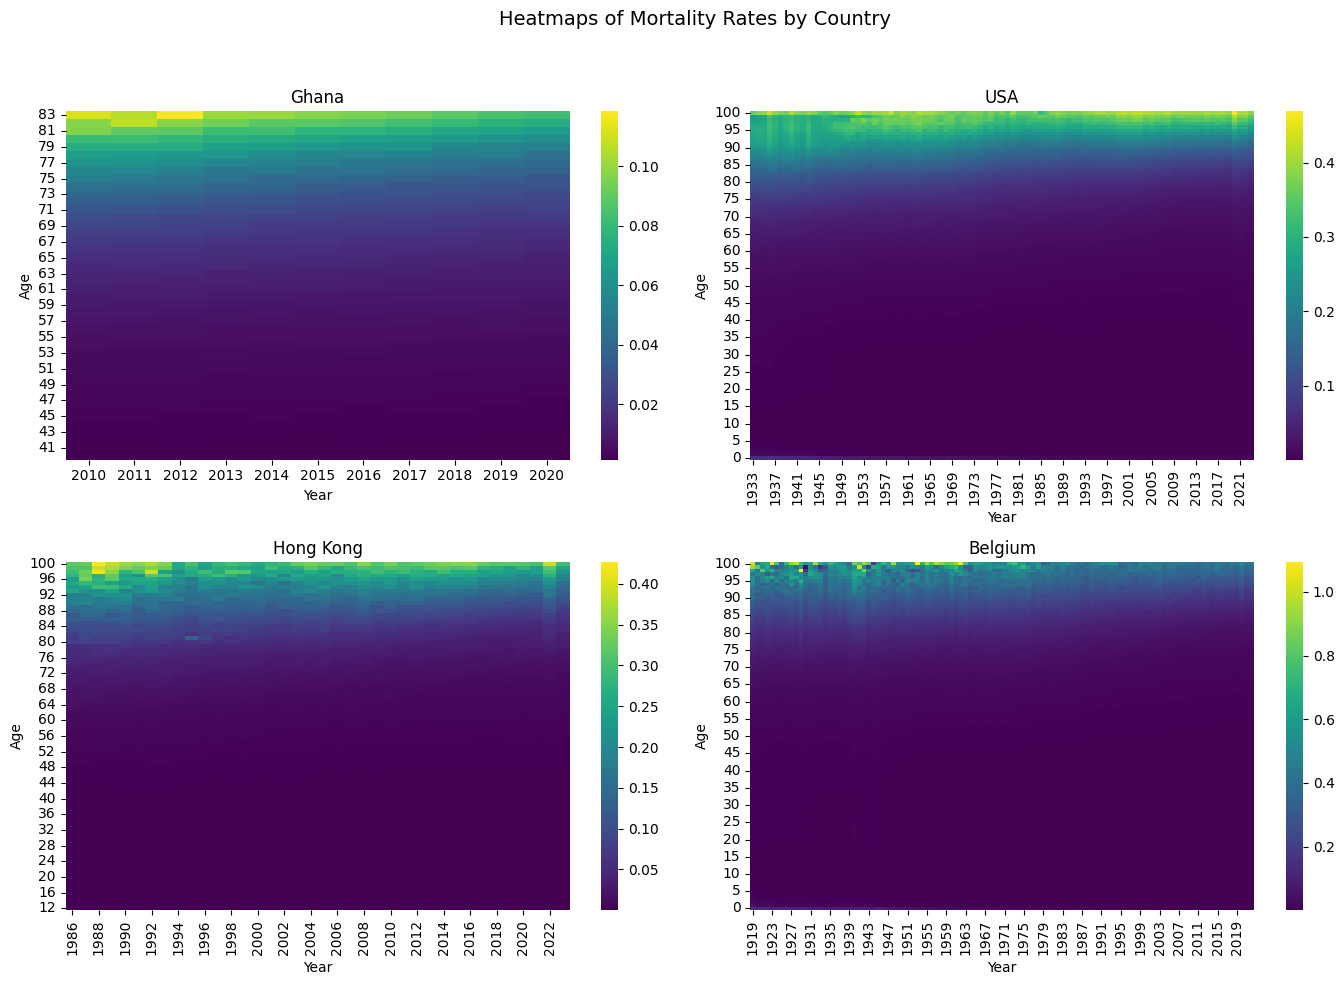

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (country, mort_df) in zip(axes, mortality_dict.items()):
    sns.heatmap(
        mort_df.sort_index(ascending=False),
        cmap="viridis",
        ax=ax
    )
    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("Age")

plt.suptitle("Heatmaps of Mortality Rates by Country", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot as a PNG image
#plt.savefig('heatmap_mortality.png')

plt.show()

# Now download the plot
#files.download('heatmap_mortality.png')


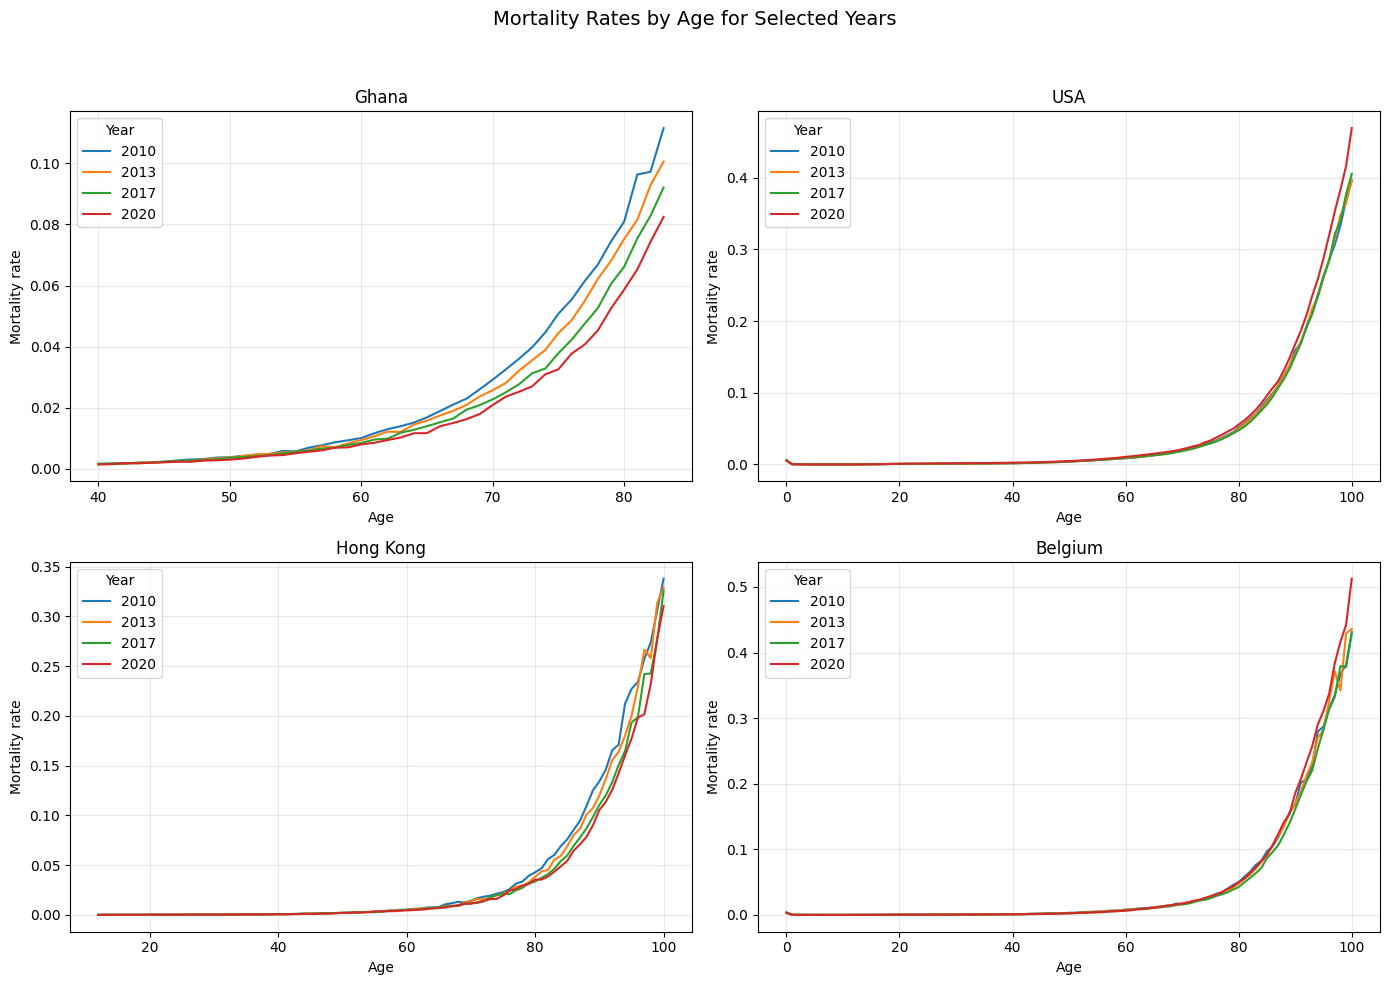

In [8]:
years = [2010, 2013, 2017, 2020]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (country, mort_df) in zip(axes, mortality_dict.items()):
    mort_df[years].plot(ax=ax)

    ax.set_title(country)
    ax.set_xlabel("Age")
    ax.set_ylabel("Mortality rate")
    ax.legend(title="Year")
    ax.grid(True, alpha=0.3)

plt.suptitle("Mortality Rates by Age for Selected Years", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot as a PNG image
plt.savefig('mortality_trend_by_age.png')

plt.show()

# Now download the plot
#files.download('mortality_trend_by_age.png')


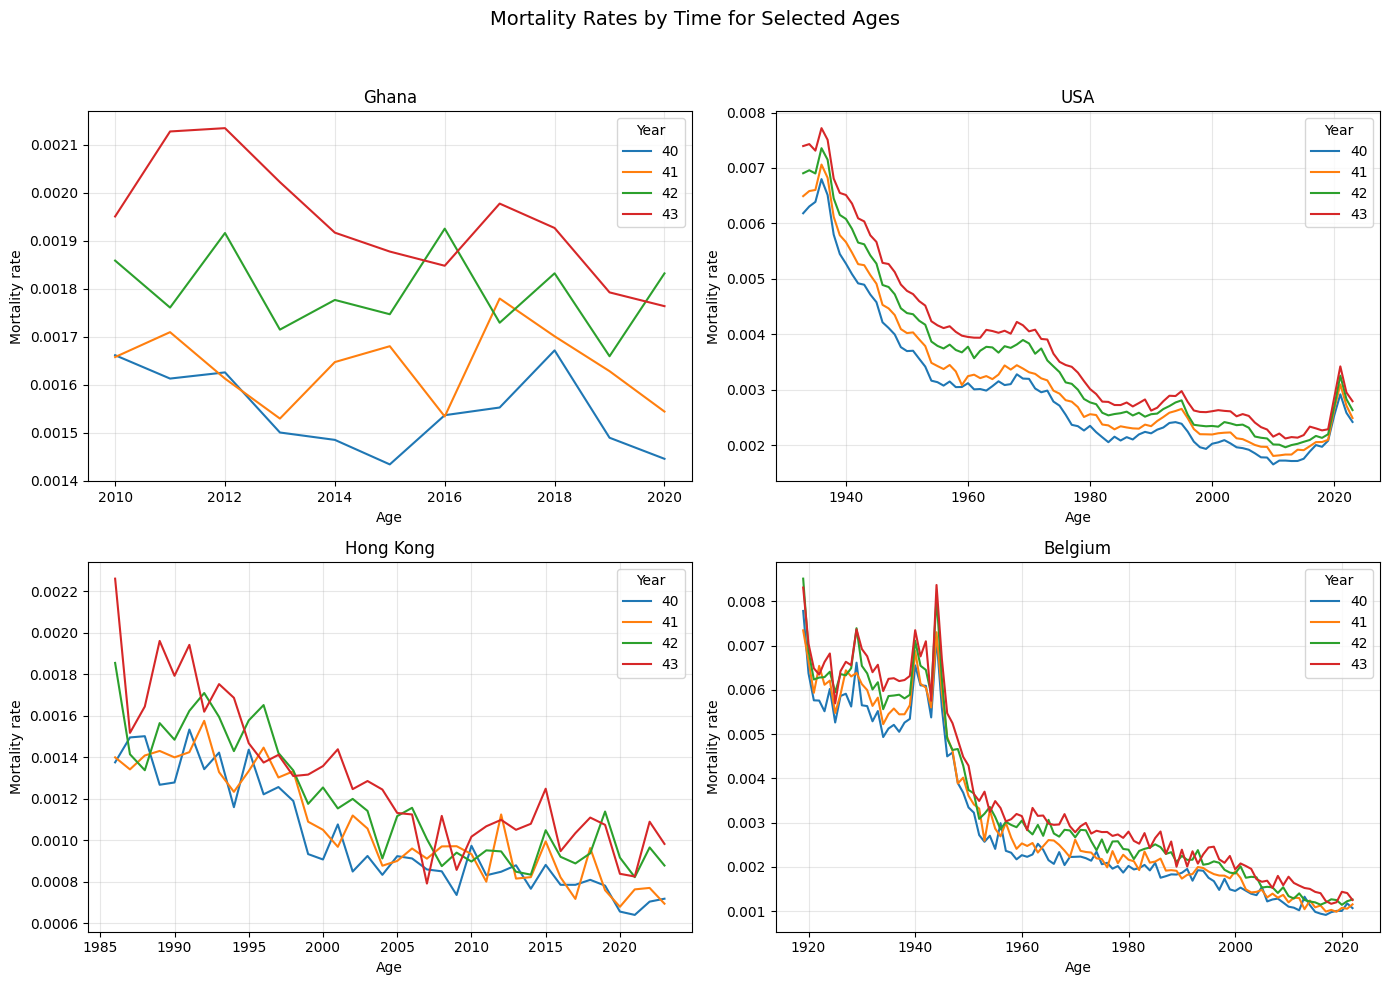

In [9]:
years = [40, 41, 42, 43]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (country, mort_df) in zip(axes, mortality_dict.items()):
    mort_df.T[years].plot(ax=ax)

    ax.set_title(country)
    ax.set_xlabel("Age")
    ax.set_ylabel("Mortality rate")
    ax.legend(title="Year")
    ax.grid(True, alpha=0.3)

plt.suptitle("Mortality Rates by Time for Selected Ages", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot as a PNG image
plt.savefig('mortality_trend_by_time.png')

plt.show()

# Now download the plot
#files.download('mortality_trend_by_time.png')

**Lee Carter Parameter Estimation**

In [10]:
lc_results = {}

for country, mort_df in mortality_dict.items():

    # Train–test split
    train_df, test_df, horizon = train_test_split_lc(
        mort_df,
        CONFIG["train_ratio"]
    )

    # Lee–Carter estimation
    ax, bx, kt = estimate_lee_carter(train_df)

    # Store everything neatly
    lc_results[country] = {
        "train_df": train_df,
        "test_df": test_df,
        "horizon": horizon,
        "ax": ax,
        "bx": bx,
        "kt": kt,
        "ages": train_df.columns.values,
        "years": train_df.index.values
    }


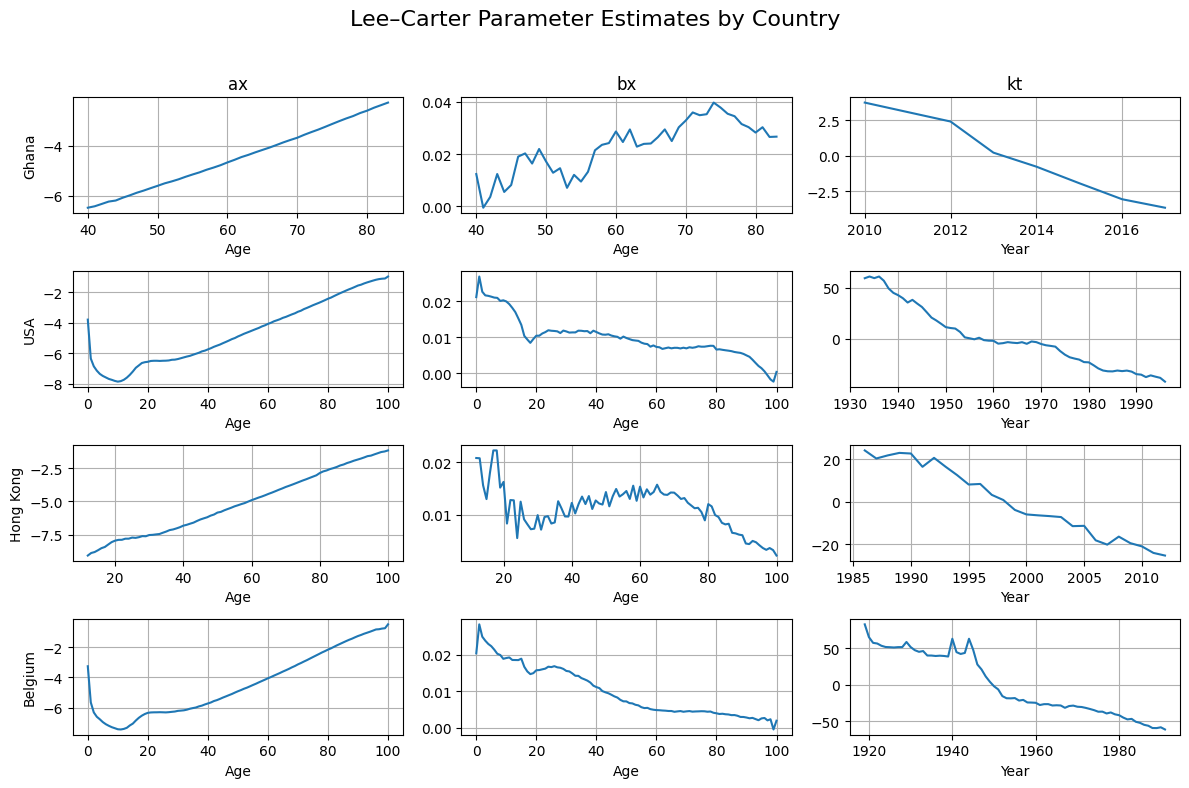

In [11]:
countries = list(lc_results.keys())
n_countries = len(countries)

fig, axes = plt.subplots(
    n_countries, 3,
    figsize=(12, 2 * n_countries),
    squeeze=False
)

for i, country in enumerate(countries):

    res = lc_results[country]

    ax_vals = res["ax"]
    bx_vals = res["bx"]
    kt_vals = res["kt"]
    ages    = res["ages"]
    years   = res["years"]

    # --- ax ---
    if hasattr(ax_vals, "index"):
        axes[i, 0].plot(ax_vals.index, ax_vals.values)
        axes[i, 0].set_xlabel("Age")
    else:
        axes[i, 0].plot(ages, ax_vals)
        axes[i, 0].set_xlabel("Age")

    axes[i, 0].set_title("ax" if i == 0 else "")
    axes[i, 0].set_ylabel(country)
    axes[i, 0].grid(True)

    # --- bx ---
    axes[i, 1].plot(ages, bx_vals)
    axes[i, 1].set_title("bx" if i == 0 else "")
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].grid(True)

    # --- kt ---
    axes[i, 2].plot(years, kt_vals)
    axes[i, 2].set_title("kt" if i == 0 else "")
    axes[i, 2].set_xlabel("Year")
    axes[i, 2].grid(True)

# overall title
fig.suptitle("Lee–Carter Parameter Estimates by Country", fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# save as single PNG
out_path = "ax_bx_kt.png"
os.makedirs("figs", exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()

# Now download the plot
#files.download('ax_bx_kt.png')

**Model Evaluation on Training Data**

In [12]:
lc_predictions = {}

for country, res in lc_results.items():

    ax = res["ax"]
    bx = res["bx"]
    kt = res["kt"]
    ages = res["ages"]
    years = res["years"]
    train_df = res["train_df"].T

    # Lee–Carter fitted values (training)
    mx_hat = lee_carter_model(ax, bx, kt)

    # Put into DataFrame with correct axes
    pred_df = pd.DataFrame(
        mx_hat,
        index=ages,
        columns=years
    )

    lc_predictions[country] = {
        "actual": train_df,
        "predicted": pred_df
    }


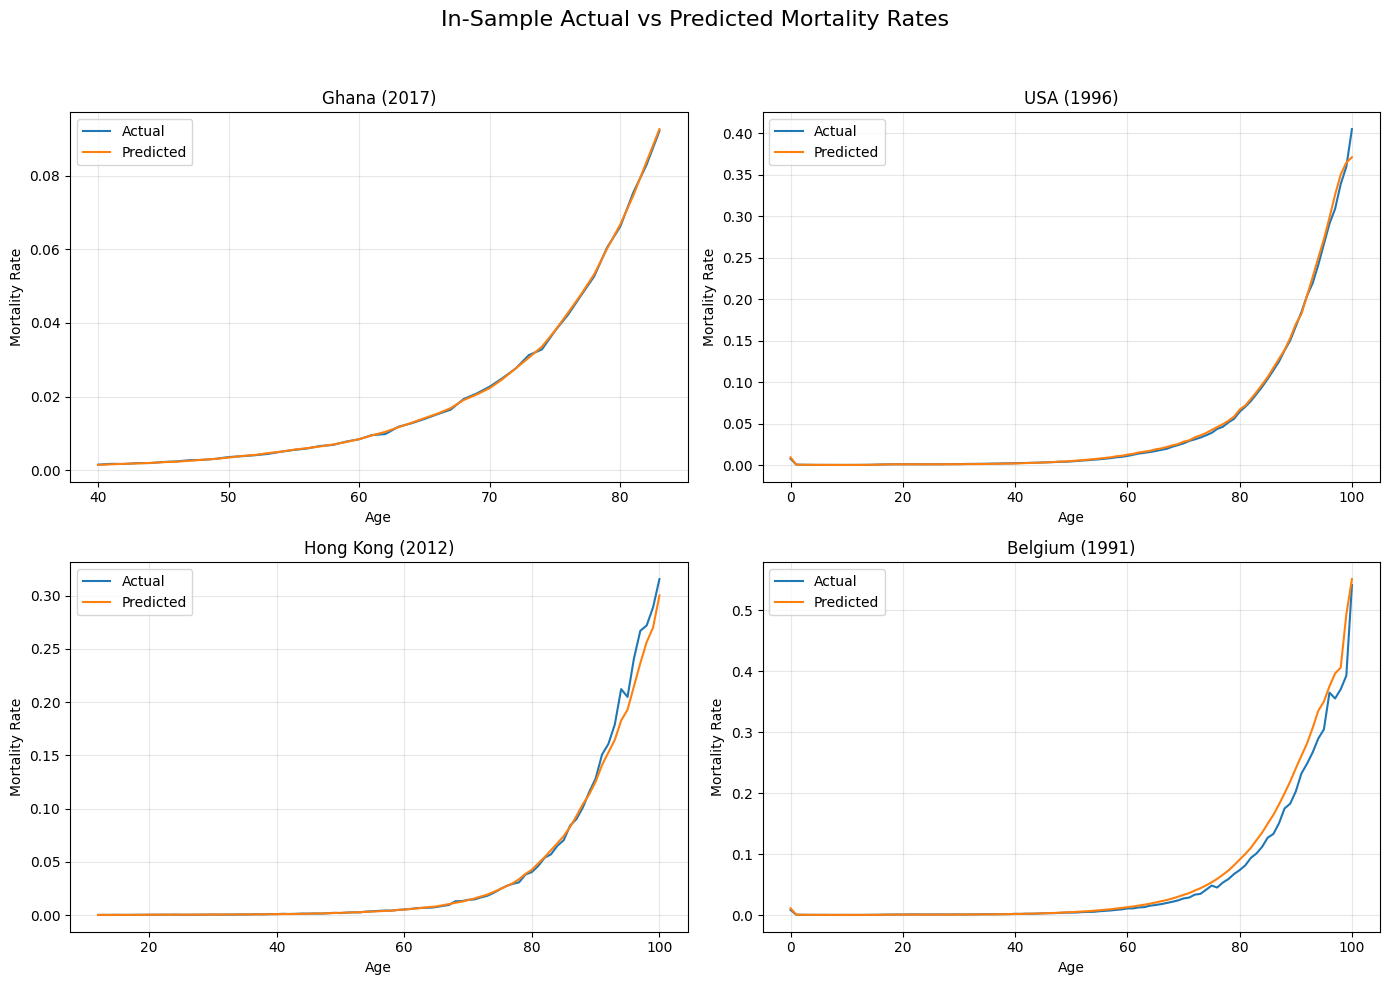

In [13]:
countries = list(lc_predictions.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, country in zip(axes, countries):

    actual_df = lc_predictions[country]["actual"]
    pred_df   = lc_predictions[country]["predicted"]

    last_year = actual_df.columns[-1]   # only the last year

    ax.plot(
        actual_df.index,
        actual_df[last_year],
        label="Actual"
    )

    ax.plot(
        pred_df.index,
        pred_df[last_year],
        label="Predicted"
    )

    ax.set_title(f"{country} ({last_year})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Mortality Rate")

    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "In-Sample Actual vs Predicted Mortality Rates",
    fontsize=16
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

# Save
os.makedirs("figs", exist_ok=True)
out_path = "in_sample_fit.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()

# Now download the plot
#files.download('in_sample_fit.png')

In [14]:
training_metrics = {}

for country, data in lc_results.items():
    actual = data["train_df"].T
    predicted = lee_carter_model(data["ax"], data["bx"], data["kt"])
    predicted_df = pd.DataFrame(predicted, index=actual.index, columns=actual.columns)

    metric_df = build_metric_table(actual, predicted_df)
    training_metrics[country] = metric_df

# Display metrics
for country, df in training_metrics.items():
    print(f"\n=== Training Metrics: {country} ===")
    display(df)



=== Training Metrics: Ghana ===


,Lee-Carter
MSE,7.437439e-07
RMSE,8.624059e-04
MAE,3.471249e-04
MAPE (%),1.931956e+00



=== Training Metrics: USA ===


,Lee-Carter
MSE,5.324194e-05
RMSE,7.296707e-03
MAE,3.100424e-03
MAPE (%),5.965210e+00



=== Training Metrics: Hong Kong ===


,Lee-Carter
MSE,9.471466e-05
RMSE,9.732146e-03
MAE,3.225671e-03
MAPE (%),8.736496e+00



=== Training Metrics: Belgium ===


,Lee-Carter
MSE,9.416364e-04
RMSE,3.068609e-02
MAE,8.125640e-03
MAPE (%),8.907005e+00


**Evaluation on Test**

In [15]:
# Dictionary to store CUSUM break points per country
cusum_breaks = {}
cusum_w_all = {}

for country, data in lc_results.items():
    kt = data["kt"]  # Extract kt from LC results
    breaks_df = cusum_weighted_breaks(kt, CONFIG["cusum_v_values"])

    # Store
    _, cusum_w_all[country] = breaks_df

for country, df in cusum_w_all.items():
    df["Year"] = np.tile(lc_results[country]["years"][1:-1], 5)
    df = df[['v', 'k', 'Year', 'CUSUM']]
    cusum_breaks[country] = df.loc[df.groupby("v")["CUSUM"].idxmax()].sort_values("v")


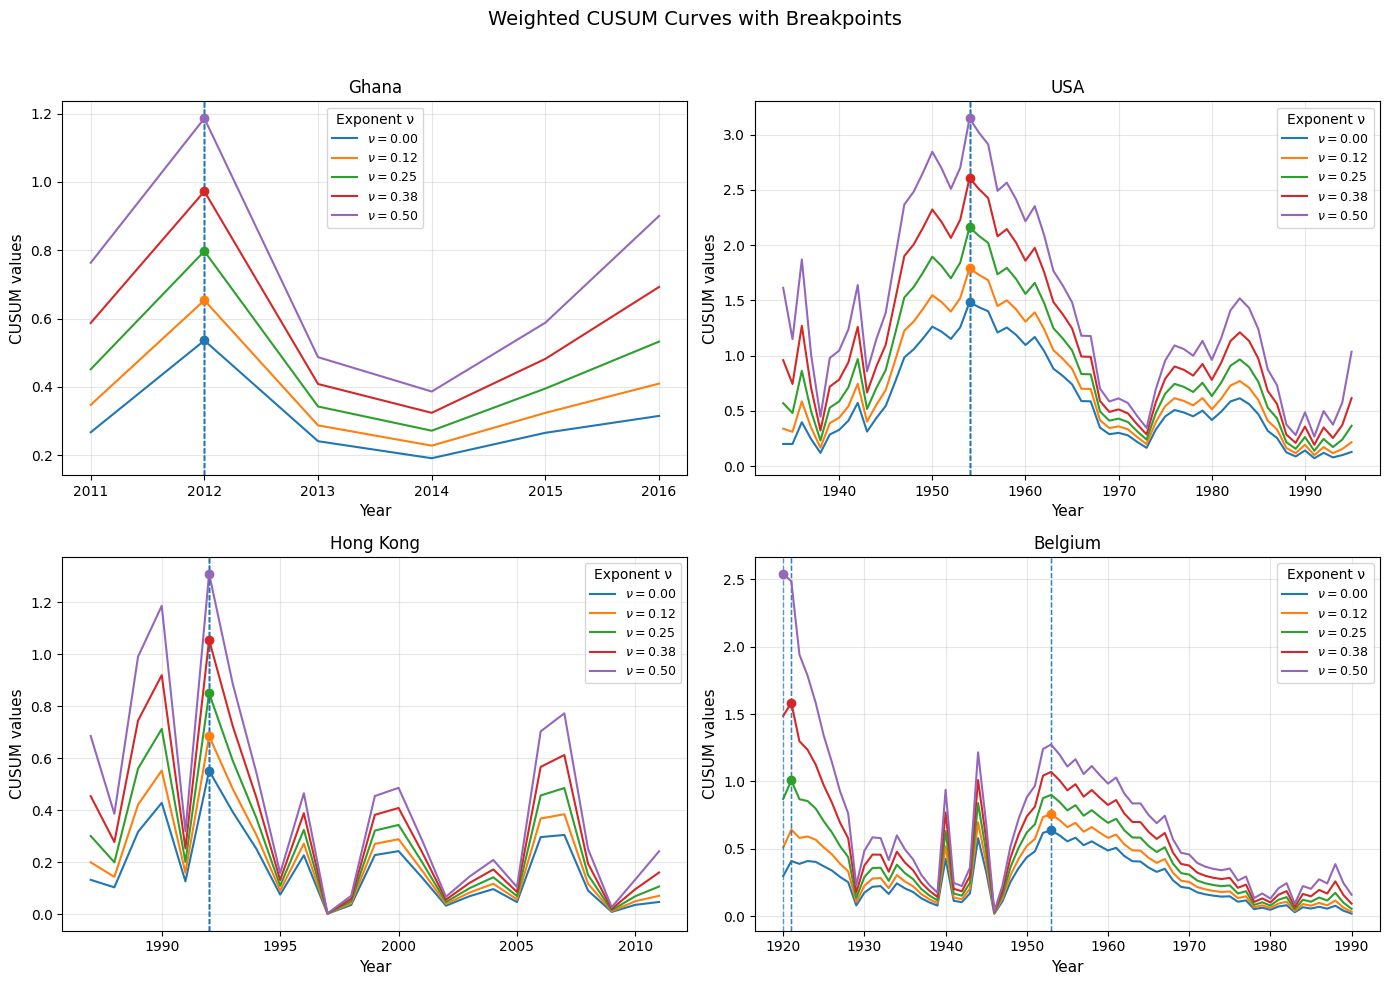

In [16]:
# 2x2 subplot layout for 4 countries
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flatten to index easily

for i, (country, df_cusum) in enumerate(cusum_w_all.items()):
    ax = axes[i]
    years = lc_results[country]["years"]

    # First difference years
    diff_years = years[1:-1]  # length = len(kt) - 1

    # Compute breakpoints per v
    breaks_by_v = df_cusum.loc[df_cusum.groupby("v")["CUSUM"].idxmax()].sort_values("v")

    for v, df_v in df_cusum.groupby("v"):
        # Plot CUSUM curve using mapped years
        ax.plot(diff_years, df_v["CUSUM"], label=fr"$\nu = {v:.2f}$")

        # Breakpoint
        k_hat = int(breaks_by_v.loc[breaks_by_v["v"] == v, "k"].values[0])
        year_hat = diff_years[k_hat - 1]  # k=1 maps to first year in diff_years
        y_hat = df_v.loc[df_v["k"] == k_hat, "CUSUM"].values[0]

        # Vertical line and marker
        ax.axvline(x=year_hat, linestyle="--", linewidth=1, alpha=0.7)
        ax.scatter(year_hat, y_hat, zorder=5)

    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("CUSUM values", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Exponent ν", fontsize=9)

plt.suptitle("Weighted CUSUM Curves with Breakpoints", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])


# Save the plot as a PNG image
plt.savefig('cusum_brk.png')

plt.show()

# Now download the plot
#files.download('cusum_brk.png')


In [17]:
# Display results
for country, df in cusum_breaks.items():
    print(f"\n=== CUSUM Weighted Breaks: {country} ===")
    display(df)


=== CUSUM Weighted Breaks: Ghana ===


,v,k,Year,CUSUM
1,0.000,2,2012,0.535948
7,0.125,2,2012,0.653728
13,0.250,2,2012,0.797392
19,0.375,2,2012,0.972627
25,0.500,2,2012,1.186372



=== CUSUM Weighted Breaks: USA ===


,v,k,Year,CUSUM
20,0.000,21,1954,1.483176
82,0.125,21,1954,1.789964
144,0.250,21,1954,2.160209
206,0.375,21,1954,2.607038
268,0.500,21,1954,3.146291



=== CUSUM Weighted Breaks: Hong Kong ===


,v,k,Year,CUSUM
5,0.000,6,1992,0.551886
30,0.125,6,1992,0.685007
55,0.250,6,1992,0.850238
80,0.375,6,1992,1.055325
105,0.500,6,1992,1.309881



=== CUSUM Weighted Breaks: Belgium ===


,v,k,Year,CUSUM
33,0.000,34,1953,0.636215
104,0.125,34,1953,0.756884
143,0.250,2,1921,1.008193
214,0.375,2,1921,1.583474
284,0.500,1,1920,2.542052


In [18]:
all_country_forecasts = {}

for country, res in lc_results.items():

    ax = res["ax"]
    bx = res["bx"]
    kt = res["kt"]
    horizon = res["horizon"]
    test_df = res["test_df"].T
    ages = res["ages"]

    # --- Forecast kt paths ---
    forecasts = forecast_all_scenarios(
        ax=ax,
        bx=bx,
        kt=kt,
        breaks=cusum_breaks[country]["k"].unique(),
        break_y=cusum_breaks[country]["Year"].unique(),
        horizon=horizon
    )

    # --- Wrap into DataFrames (ages × test years) ---
    forecast_dfs = wrap_forecasts_as_df(
        forecasts,
        test_years=test_df.columns,
        ages=ages
    )

    all_country_forecasts[country] = {
        "actual": test_df,
        "forecasts": forecast_dfs
    }


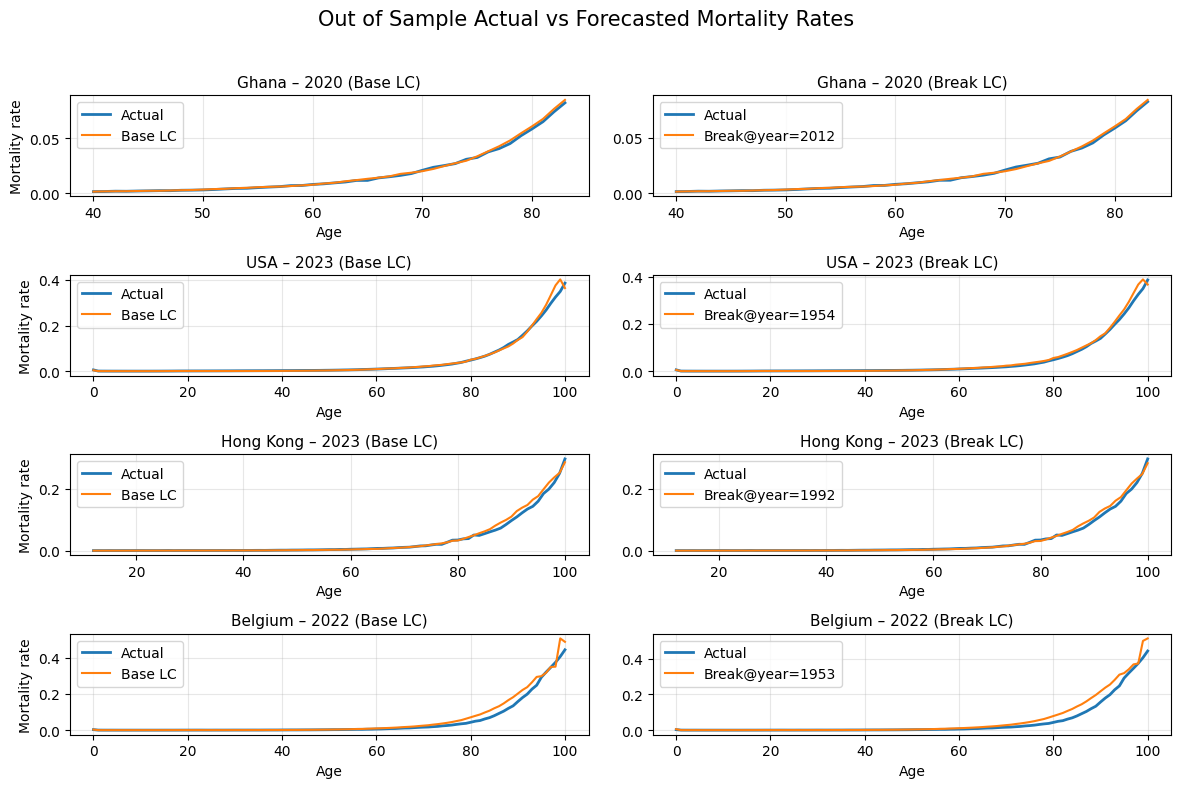

In [19]:
plot_base_vs_break_all_countries(
    all_country_forecasts,
    save_path="figs/out_sample_fit_brk.png",
)

# Now download the plot
#files.download('figs/out_sample_fit_brk.png')

In [20]:
forecast_metrics = {}

for country, data in all_country_forecasts.items():
    actual_df = data["actual"]
    forecast_dfs = data["forecasts"]

    metric_df = build_country_forecast_metrics(actual_df, forecast_dfs)
    forecast_metrics[country] = metric_df

for country, df in forecast_metrics.items():
    print(f"\n=== Forecast Metrics: {country} ===")
    display(df)




=== Forecast Metrics: Ghana ===


,Base LC,Break@year=2012
MSE,8.374136e-07,5.300290e-07
RMSE,9.151030e-04,7.280309e-04
MAE,5.588956e-04,4.620698e-04
MAPE (%),3.582255e+00,3.298566e+00



=== Forecast Metrics: USA ===


,Base LC,Break@year=1954
MSE,4.330141e-05,3.873036e-05
RMSE,6.580381e-03,6.223372e-03
MAE,2.626630e-03,2.722256e-03
MAPE (%),1.334295e+01,1.282922e+01



=== Forecast Metrics: Hong Kong ===


,Base LC,Break@year=1992
MSE,7.176296e-05,7.224337e-05
RMSE,8.471302e-03,8.499610e-03
MAE,3.176624e-03,3.081191e-03
MAPE (%),1.517913e+01,1.576639e+01



=== Forecast Metrics: Belgium ===


,Base LC,Break@year=1953,Break@year=1921,Break@year=1920
MSE,4.085247e-04,5.466358e-04,4.508478e-04,4.382882e-04
RMSE,2.021199e-02,2.338024e-02,2.123318e-02,2.093533e-02
MAE,9.726716e-03,1.165180e-02,1.036004e-02,1.017867e-02
MAPE (%),2.766040e+01,3.236329e+01,2.828476e+01,2.802537e+01


**Comparing Models**

In [21]:
# helper functions

def retrieve_datas_(file_name, const):

    with open(file_name) as f:
        g = f.readlines()

    data = []

    for item in g:
        l = item.strip().split(' ')
        d = []
        for e in l:
            e = e.strip('+')
            if len(e) >= 1:
                if e == '.':
                    d.append(0)
                else:
                    d.append(e)

        data.append(d)

    year = []
    age = []
    female = []
    male = []
    total = []

    for el in data[3:]:
        year.append(int(el[0]))
        age.append(int(el[1]))
        female.append(float(el[2]))
        male.append(float(el[3]))
        total.append(float(el[4]))

    dd = {}
    dd['Year'] = year
    dd['Age'] = age
    dd['Female'] = female
    dd['Male'] = male
    dd[const] = total

    return pd.DataFrame(dd)


def retrieve_datas_into_one(file_mx, file_exp, file_death):

    data_mx = retrieve_datas_(file_mx, "Mx")
    data_exp = retrieve_datas_(file_exp, "Exposure")
    data_death = retrieve_datas_(file_death, "Deaths")

    df = {}
    df["Year"] = data_mx["Year"]
    df["Age"] = data_exp["Age"]
    df["Exposure"] = data_exp["Exposure"]
    df["Deaths"] = data_death["Deaths"]
    df["Mx"] = data_mx["Mx"]
    df = pd.DataFrame(df)
    p = df.index[df["Year"] == data_mx["Year"][len(data_mx["Year"])-1]][-1]
    df = df.iloc[:p, :]

    return df


def find_globally_valid_start_year_(df, min_age, max_age):

    years = np.sort(df['Year'].unique())

    # Precompute validity of each year
    year_valid = {}

    for y in years:
        sub = df[
            (df['Year'] == y) &
            (df['Age'] >= min_age) &
            (df['Age'] <= max_age)
        ]

        # Full age coverage
        if sub['Age'].nunique() != (max_age - min_age + 1):
            year_valid[y] = False
            continue

        mx = sub['Total'].values
        year_valid[y] = np.all(np.isfinite(mx)) and np.all(mx > 0)

    # Find earliest year such that ALL later years are valid
    for i, y in enumerate(years):
        if all(year_valid[yy] for yy in years[i:]):
            return y

    raise ValueError(
        "No contiguous block of years with complete mx data for the chosen age range."
    )


def prep_mortality_dfs(df, df_ref, config):

    # find first year with valid mx
    min_year = find_globally_valid_start_year_(
        df_ref,
        config["min_age"],
        config["max_age"]
    )

    # drop everything before (and including invalid years)
    df = df[df['Year'] >= min_year].copy()

    max_year = df['Year'].max()

    df = df[
        (df['Age'] >= config["min_age"]) &
        (df['Age'] <= config["max_age"])
    ].reset_index(drop=True)

    return df



def fit_poisson_lc_pipeline(mort_df_long, config):

    # -------------------------------
    # 1. Train / test split by year
    # -------------------------------

    years_all = mort_df_long["Year"].unique()
    split_idx = int(len(years_all) * config["train_ratio"])
    split_year = int(years_all[split_idx])

    train = mort_df_long[mort_df_long["Year"] <= split_year].copy()
    test  = mort_df_long[mort_df_long["Year"] > split_year].copy()

    ages  = np.sort(train["Age"].unique())
    years = np.sort(train["Year"].unique())

    # -------------------------------
    # 2. SVD Lee–Carter
    # -------------------------------
    mx = (
        train.pivot(index="Age", columns="Year", values="Deaths") /
        train.pivot(index="Age", columns="Year", values="Exposure")
    )

    log_mx = np.log(mx)

    ax_svd = log_mx.mean(axis=1)
    M = (log_mx.sub(ax_svd, axis=0)).values

    U, s, Vt = np.linalg.svd(M, full_matrices=False)

    bx_svd = pd.Series(U[:, 0], index=ages)
    bx_svd = bx_svd / bx_svd.sum()

    kt_svd = pd.Series(s[0] * Vt[0] * bx_svd.sum(), index=years)

    # -------------------------------
    # 3. Poisson LC (Brouhns et al.)
    # -------------------------------
    age_d = pd.get_dummies(train["Age"]).reindex(columns=ages, fill_value=0)
    year_d = pd.get_dummies(train["Year"]).reindex(columns=years, fill_value=0)

    bx_vec = train["Age"].map(bx_svd).values
    Z = year_d.mul(bx_vec[:, None])

    X = pd.concat([age_d, Z], axis=1).astype(float)

    model = sm.GLM(
        train["Deaths"].values,
        X.values,
        family=sm.families.Poisson(),
        offset=np.log(train["Exposure"].values)
    )

    res = model.fit()

    n_age = len(ages)

    ax_plc = pd.Series(res.params[:n_age], index=ages)
    kt_plc = pd.Series(res.params[n_age:], index=years)
    kt_plc = kt_plc - kt_plc.mean()

    # -------------------------------
    # 4. Forecast kt (RW + drift)
    # -------------------------------
    rw = ARIMA(kt_plc, order=(0, 1, 0), trend="t").fit()

    n_forecast = test["Year"].nunique()
    kt_fc = rw.forecast(steps=n_forecast)
    kt_fc.index = np.sort(test["Year"].unique())

    # -------------------------------
    # 5. Predict mortality
    # -------------------------------
    def predict_mortality(ax, bx, kt, ages, years):
        log_m = (
            ax.loc[ages].values[:, None] +
            bx.loc[ages].values[:, None] * kt.loc[years].values[None, :]
        )
        return np.exp(log_m)

    pred_mx = predict_mortality(
        ax=ax_plc,
        bx=bx_svd,
        kt=kt_fc,
        ages=ages,
        years=kt_fc.index
    )

    pred_mx_df = pd.DataFrame(
        pred_mx,
        index=ages,
        columns=kt_fc.index
    )

    return {
        "train": train,
        "test": test,
        "ages": ages,
        "years_train": years,
        "ax": ax_plc,
        "bx": bx_svd,
        "kt_train": kt_plc,
        "kt_forecast": kt_fc,
        "predicted": pred_mx_df
    }



def actual_mx_from_test(test_df):
    mx = (
        test_df.pivot(index="Age", columns="Year", values="Deaths") /
        test_df.pivot(index="Age", columns="Year", values="Exposure")
    )
    return mx



def predict_mortality_plch(ax, bx, kt, cx, gamma, ages, years):

    ages  = np.asarray(ages)
    years = np.asarray(years)

    cohort = years[None, :] - ages[:, None]
    gamma_mat = np.zeros_like(cohort, dtype=float)

    gamma_index = gamma.index.astype(int)

    for i in range(cohort.shape[0]):
        for j in range(cohort.shape[1]):
            c = int(cohort[i, j])
            if c in gamma_index:
                gamma_mat[i, j] = gamma.loc[c]

    log_mx = (
        ax.loc[ages].values[:, None]
        + bx.loc[ages].values[:, None] * kt.loc[years].values[None, :]
        + cx.loc[ages].values[:, None] * gamma_mat
    )

    return np.exp(log_mx)



def fit_plch_model(mort_df_long, train_ratio, arima_order=(0, 1, 0)):

    df = mort_df_long.copy()

    # ============================================================
    # 1. TRAIN / TEST SPLIT
    # ============================================================

    years_all = np.sort(df["Year"].unique())
    split_idx = int(len(years_all) * train_ratio)
    split_year = int(years_all[split_idx])

    train = df[df["Year"] <= split_year].copy()
    test  = df[df["Year"] > split_year].copy()

    train["cohort"] = train["Year"] - train["Age"]
    test["cohort"]  = test["Year"] - test["Age"]

    ages    = np.sort(train["Age"].unique())
    years   = np.sort(train["Year"].unique())
    cohorts = np.sort(train["cohort"].unique())

    # ============================================================
    # 2. SVD LEE–CARTER (baseline)
    # ============================================================

    mx = (
        train.pivot(index="Age", columns="Year", values="Deaths") /
        train.pivot(index="Age", columns="Year", values="Exposure")
    )

    log_mx = np.log(mx)
    ax_svd = log_mx.mean(axis=1)

    M = log_mx.sub(ax_svd, axis=0).values
    U, s, Vt = np.linalg.svd(M, full_matrices=False)

    bx_svd = pd.Series(U[:, 0], index=ages)
    bx_svd /= bx_svd.sum()

    kt_svd = pd.Series(s[0] * Vt[0] * bx_svd.sum(), index=years)

    cx_svd = pd.Series(np.ones(len(ages)) / len(ages), index=ages)

    # ============================================================
    # 3. POISSON LC + COHORT (PLCH)
    # ============================================================

    age_d    = pd.get_dummies(train["Age"]).reindex(columns=ages, fill_value=0)
    year_d   = pd.get_dummies(train["Year"]).reindex(columns=years, fill_value=0)
    cohort_d = pd.get_dummies(train["cohort"]).reindex(columns=cohorts, fill_value=0)

    bx_vec = train["Age"].map(bx_svd).values
    cx_vec = train["Age"].map(cx_svd).values

    Z_period = year_d.mul(bx_vec[:, None])
    Z_cohort = cohort_d.mul(cx_vec[:, None])

    X = pd.concat([age_d, Z_period, Z_cohort], axis=1).astype(float)

    model = sm.GLM(
        train["Deaths"].values,
        X.values,
        family=sm.families.Poisson(),
        offset=np.log(train["Exposure"].values)
    )

    res = model.fit()

    # ============================================================
    # 4. PARAMETER EXTRACTION
    # ============================================================

    n_age    = len(ages)
    n_year   = len(years)
    n_cohort = len(cohorts)

    ax = pd.Series(res.params[:n_age], index=ages)

    kt = pd.Series(
        res.params[n_age:n_age + n_year],
        index=years
    )
    kt -= kt.mean()

    gamma = pd.Series(
        res.params[n_age + n_year:],
        index=cohorts
    )
    gamma -= gamma.mean()

    # ============================================================
    # 5. FORECAST kt
    # ============================================================

    rw = ARIMA(kt, order=arima_order, trend="t").fit()

    future_years = np.sort(test["Year"].unique())

    kt_forecast = rw.forecast(steps=len(future_years))
    kt_forecast.index = future_years

    # ============================================================
    # 6. MORTALITY PREDICTION (TEST)
    # ============================================================

    mx_pred = predict_mortality_plch(
        ax=ax,
        bx=bx_svd,
        kt=kt_forecast,
        cx=cx_svd,
        gamma=gamma,
        ages=ages,
        years=future_years
    )

    mx_pred = pd.DataFrame(mx_pred, index=ages, columns=future_years)

    mx_actual = actual_mx_from_test(test)

    mx_actual, mx_pred = mx_actual.align(mx_pred, join="inner")

    # ============================================================
    # 7. ERROR METRICS
    # ============================================================

    y_true = mx_actual.values.ravel()
    y_pred = mx_pred.values.ravel()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    metrics = pd.DataFrame(
        {
            "MSE":  [f"{mse:.6e}"],
            "RMSE": [f"{rmse:.6e}"],
            "MAE":  [f"{mae:.6e}"],
            "MAPE (%)": [f"{mape:.6e}"]
        },
        index=["PLCH"]
    )

    # ============================================================
    # 8. RETURN EVERYTHING
    # ============================================================

    return {
        "train": train,
        "test": test,
        "params": {
            "ax": ax,
            "bx": bx_svd,
            "kt": kt,
            "gamma": gamma
        },
        "kt_forecast": kt_forecast,
        "mx_actual": mx_actual,
        "mx_pred": mx_pred,
        "metrics": metrics
    }



def predict_mortality_bplc(ax, bx, kt, ages, years):

    ages  = np.asarray(ages)
    years = np.asarray(years)

    log_mx = (
        ax.loc[ages].values[:, None]
        + bx.loc[ages].values[:, None] * kt.loc[years].values[None, :]
    )

    return np.exp(log_mx)



def fit_lc_break_model(mort_df_long, train_ratio, n_breaks=1):

    df = mort_df_long.copy()

    # ============================================================
    # 1. TRAIN / TEST SPLIT
    # ============================================================

    years_all = np.sort(df["Year"].unique())
    split_idx = int(len(years_all) * train_ratio)
    split_year = int(years_all[split_idx])

    train = df[df["Year"] <= split_year].copy()
    test  = df[df["Year"] > split_year].copy()

    ages  = np.sort(train["Age"].unique())
    years = np.sort(train["Year"].unique())

    # ============================================================
    # 2. SVD LEE–CARTER
    # ============================================================

    mx = (
        train.pivot(index="Age", columns="Year", values="Deaths") /
        train.pivot(index="Age", columns="Year", values="Exposure")
    )

    log_mx = np.log(mx)

    ax = log_mx.mean(axis=1)

    M = log_mx.sub(ax, axis=0).values
    U, s, Vt = np.linalg.svd(M, full_matrices=False)

    bx = pd.Series(U[:, 0], index=ages)
    bx /= bx.sum()

    kt = pd.Series(s[0] * Vt[0] * bx.sum(), index=years)

    kt.index = pd.Index(kt.index.astype(int), name="Year")

    # ============================================================
    # 3. BREAK DETECTION ON kt
    # ============================================================

    kt_series = kt.values.reshape(-1, 1)
    kt_years  = kt.index.values

    algo = rpt.Binseg(model="linear").fit(kt_series)
    breaks = algo.predict(n_bkps=n_breaks)

    break_years = [kt_years[b - 1] for b in breaks[:-1]]
    has_break   = len(break_years) > 0
    break_year  = break_years[0] if has_break else None

    # ============================================================
    # 4. EXOGENOUS DUMMY (BREAK IN DRIFT)
    # ============================================================

    if has_break:
        D = (kt.index > break_year).astype(int)
    else:
        D = np.zeros(len(kt), dtype=int)

    exog = pd.DataFrame({"break_dummy": D}, index=kt.index)

    # ============================================================
    # 5. ARIMA: RW + DRIFT + BREAK IN DRIFT
    # ============================================================

    model_kt = ARIMA(
        kt,
        order=(0, 1, 0),
        trend="t",
        exog=exog
    )

    res_kt = model_kt.fit()

    # ============================================================
    # 6. FORECAST kt
    # ============================================================

    future_years = np.sort(test["Year"].unique())
    n_forecast   = len(future_years)

    if has_break:
        D_future = (future_years > break_year).astype(int)
    else:
        D_future = np.zeros(n_forecast, dtype=int)

    exog_future = pd.DataFrame(
        {"break_dummy": D_future},
        index=future_years
    )

    kt_forecast = res_kt.forecast(
        steps=n_forecast,
        exog=exog_future
    )

    kt_forecast.index = future_years

    # 7. PREDICT TEST MORTALITY
    mx_pred = predict_mortality_bplc(
        ax=ax,
        bx=bx,
        kt=kt_forecast,
        ages=ages,
        years=future_years
    )

    mx_pred = pd.DataFrame(mx_pred, index=ages, columns=future_years)

    mx_actual = (
        test.pivot(index="Age", columns="Year", values="Deaths") /
        test.pivot(index="Age", columns="Year", values="Exposure")
    )

    mx_actual, mx_pred = mx_actual.align(mx_pred, join="inner")

    # ============================================================
    # 8. ERROR METRICS
    # ============================================================

    y_true = mx_actual.values.ravel()
    y_pred = mx_pred.values.ravel()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    metrics = pd.DataFrame(
        {
            "MSE":  [f"{mse:.6e}"],
            "RMSE": [f"{rmse:.6e}"],
            "MAE":  [f"{mae:.6e}"],
            "MAPE (%)": [f"{mape:.6e}"]
        },
        index=["LC + Break"]
    )

    # ============================================================
    # 9. RETURN EVERYTHING
    # ============================================================

    return {
        "train": train,
        "test": test,
        "params": {
            "ax": ax,
            "bx": bx,
            "kt": kt
        },
        "break_year": break_year,
        "kt_forecast": kt_forecast,
        "mx_actual": mx_actual,
        "mx_pred": mx_pred,
        "metrics": metrics
    }


In [22]:
df_belg = retrieve_datas_into_one('Mx_Belgium_1x1.txt', 'Exposures_Belgium_1x1.txt', 'Deaths_Belgium_1x1.txt')
df_belg = prep_mortality_dfs(df_belg, df_bel, CONFIG)

df_usas = retrieve_datas_into_one('Mx_USA_1x1.txt', 'Exposures_USA_1x1.txt', 'Deaths_USA_1x1.txt')
df_usas = prep_mortality_dfs(df_usas, df_usa, CONFIG)

df_hnkg = retrieve_datas_into_one('Mx_HongKong_1x1.txt', 'Exposures_HongKong_1x1.txt', 'Deaths_HongKong_1x1.txt')
df_hnkg = prep_mortality_dfs(df_hnkg, df_hnk, CONFIG_hnk)

# Ghana
df_ = pd.read_csv("DeathsGH.csv")

# rename first column
df_ = df_.rename(columns={df_.columns[0]: "Age"})

new_cols = ["Age"]
years = []

for i, col in enumerate(df_.columns[1:]):
    year = 2010 + i // 2
    years.append(year)

    if i % 2 == 0:
        new_cols.append(f"{year}_deaths")
    else:
        new_cols.append(f"{year}_exposure")

df_.columns = new_cols

records = []

for year in sorted(set(y for y in years)):
    for _, row in df_.iterrows():
        records.append({
            "Age": row["Age"],
            "Year": year,
            "Deaths": row[f"{year}_deaths"],
            "Exposure": row[f"{year}_exposure"]
        })

df_gh = pd.DataFrame(records)
df_gh = df_gh.dropna(subset=["Deaths", "Exposure"])
df_gh = df_gh[df_gh["Exposure"] > 0]

**Poisson Extension to the LC Model**

In [23]:
mortality_data = {
    "Ghana": df_gh,
    "Belgium": df_belg,
    "USA": df_usas,
    "Hong Kong": df_hnkg,
}

poisson_lc_results_all = {}

for country, mort_df in mortality_data.items():
    poisson_lc_results_all[country] = fit_poisson_lc_pipeline(
        mort_df_long=mort_df,
        config=CONFIG
    )


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

In [24]:
metrics_all_countries = {}

for country, results in poisson_lc_results_all.items():

    # --- actual test mortality ---
    actual_mx = actual_mx_from_test(results["test"])

    # --- predicted mortality ---
    pred_mx = results["predicted"]

    # --- align safely (important!) ---
    common_ages  = actual_mx.index.intersection(pred_mx.index)
    common_years = actual_mx.columns.intersection(pred_mx.columns)

    actual_aligned = actual_mx.loc[common_ages, common_years]
    pred_aligned   = pred_mx.loc[common_ages, common_years]

    # --- compute metrics ---
    metrics = lc_error_metrics(actual_aligned, pred_aligned)

    metrics_all_countries[country] = pd.DataFrame(
        metrics,
        index=["Poisson LC Forecast"]
    )


for country, df_metrics in metrics_all_countries.items():
    print(f"\n=== Forecast Error Metrics: {country} ===")
    display(df_metrics.round(6))



=== Forecast Error Metrics: Ghana ===


,MSE,RMSE,MAE,MAPE (%)
Poisson LC Forecast,1.492620e-06,1.221728e-03,7.252262e-04,4.066175e+00



=== Forecast Error Metrics: Belgium ===


,MSE,RMSE,MAE,MAPE (%)
Poisson LC Forecast,2.060233e-04,1.435351e-02,6.062600e-03,3.127537e+01



=== Forecast Error Metrics: USA ===


,MSE,RMSE,MAE,MAPE (%)
Poisson LC Forecast,4.722193e-05,6.871822e-03,2.765027e-03,1.431105e+01



=== Forecast Error Metrics: Hong Kong ===


,MSE,RMSE,MAE,MAPE (%)
Poisson LC Forecast,6.437655e-05,8.023500e-03,3.063306e-03,1.534907e+01


**Cohort-Based Extension to the Poisson Lee–Carter Model**

In [25]:
plch_results = {}

for country, df_country in mortality_data.items():
    plch_results[country] = fit_plch_model(
        df_country,
        train_ratio=CONFIG["train_ratio"]
    )


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

In [26]:
plch_metrics = {}

for country, res in plch_results.items():
    print(f"\n=== PLCH Test Metrics: {country} ===")
    plch_metrics[country] = res["metrics"]
    display(res["metrics"])



=== PLCH Test Metrics: Ghana ===


,MSE,RMSE,MAE,MAPE (%)
PLCH,1.123010e-06,1.059722e-03,6.897314e-04,5.197582e+00



=== PLCH Test Metrics: Belgium ===


,MSE,RMSE,MAE,MAPE (%)
PLCH,2.232291e-04,1.494085e-02,6.047184e-03,3.455891e+01



=== PLCH Test Metrics: USA ===


,MSE,RMSE,MAE,MAPE (%)
PLCH,4.810796e-05,6.935990e-03,2.760530e-03,1.398185e+01



=== PLCH Test Metrics: Hong Kong ===


,MSE,RMSE,MAE,MAPE (%)
PLCH,5.771070e-05,7.596756e-03,2.894308e-03,1.480847e+01
